# 🧠 Johansen CO₂ Bayesian Optimization — Individual Wells v4

## Five Independent Injectors (No Clustering)

Each well has **fully independent** parameters (Q, T_start, T_end):

| Well | Notes |
|---|---|
| `31/01/01`  | Deep well — directional injector |
| `31/1-3 S`  | Deep well — directional injector |
| `31/2-5`    | Deep well — directional injector |
| `31/05/07`  | Central injector |
| `31/07/01`  | New well — added in v4 |

## Three Physical Conditions Enforced

| # | Condition | Limit | Source |
|---|---|---|---|
| **1** | Caprock seal — BHP per injector | ≤ **324 bar** (90% of 360 bar fracture pressure) | `simulation_summary.txt` → `BHP_WELL` lines |
| **2** | CO₂ containment — boundary saturation | S_CO₂ < **15%** at both boundary wells | `SBoundary_test_well.csv` + `SBoundary_test_well_2.csv` |
| **3** | Injection window | T_end ≤ **MAX_INJECTION_YEARS** (configurable, default 100) | Search space bounds |

## Workflow
```
[Python] writes well_plan.csv  →  [You] run MATLAB simulation
[MATLAB] writes outputs to well_csvs/  →  [You] return to this notebook
[Python] reads result folder, updates Optuna (SQLite-persisted)
[Python] shows live progress chart  →  proposes next trial  →  repeat
```

## Key Changes from v3
- **No clustering** — every well independently optimized
- **15 parameters** (5 wells × 3 params each) instead of 6
- **Well roster change** — `31/05/02` removed, `31/07/01` added
- **Free-range Q bounds** — (0.0, 5.0) Mt/yr so optimizer can explore everything
- **Full time window** — T_start can range 0→95, T_end can range 5→100
- **150 trials** (10 per parameter) with 45 warm-up

In [1]:
# Cell 1 — Install dependencies
import subprocess, sys
for pkg in ['optuna', 'scikit-learn', 'joblib']:
    try:
        __import__(pkg.replace('-','_'))
        print(f'  ✅ {pkg}')
    except ImportError:
        print(f'  📦 Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✅ {pkg} installed')
print('\nAll dependencies ready.')

  ✅ optuna
  📦 Installing scikit-learn...
  ✅ scikit-learn installed
  ✅ joblib

All dependencies ready.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Cell 2 — Configuration (v4 — Individual Wells)
import os, re, glob, shutil, time, json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import clear_output, display
warnings.filterwarnings('ignore')
import optuna
from optuna.samplers import TPESampler
from optuna.distributions import FloatDistribution, IntDistribution
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── PATHS ────────────────────────────────────────────────────────────────────
MRST_ROOT      = '/Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a'
WELL_PLAN_PATH = f'{MRST_ROOT}/core/examples/data/Johansen/data/well_plan.csv'
BACKUP_CSV     = f'{MRST_ROOT}/core/examples/data/Johansen/data/well_plan_BACKUP_BO.csv'
WELL_CSVS_ROOT = f'{MRST_ROOT}/core/examples/data/Johansen/well_csvs'
PYTHON_DIR     = f'{MRST_ROOT}/core/examples/data/Johansen/python'
RESULTS_JSON   = f'{PYTHON_DIR}/bo_v4_results.json'
SIGNAL_FILE    = f'{PYTHON_DIR}/bo_signal.json'
PENDING_FILE   = f'{PYTHON_DIR}/bo_pending.json'
OPTUNA_DB      = f'sqlite:///{PYTHON_DIR}/johansen_bo_v4_individual.db'

# ─── PHYSICAL CONSTRAINTS ────────────────────────────────────────────────────
FRACTURE_PRESSURE = 360.0   # Caprock fracture pressure (bar)
BHP_SAFETY_MARGIN = 0.10    # 10% safety margin (industry standard for CCS)
BHP_LIMIT_BAR     = FRACTURE_PRESSURE * (1.0 - BHP_SAFETY_MARGIN)  # = 324.0 bar
S_CO2_THRESHOLD   = 0.15    # Critical CO₂ saturation at boundary (15%)

# ─── INJECTION WINDOW (CONFIGURABLE) ─────────────────────────────────────────
# Change MAX_INJECTION_YEARS to adjust the injection period.
# The total simulation runs 1000 years for plume migration monitoring,
# but injection can only occur within [0, MAX_INJECTION_YEARS].
MAX_INJECTION_YEARS = 100

# ─── OPTIMIZATION CONFIG ──────────────────────────────────────────────────────
N_TRIALS         = 150      # 15 params × 10 per param
N_WARMUP         = 45       # 30% of budget — essential for 15D space
POLL_TIMEOUT_SEC = 1800     # 30 min timeout waiting for MATLAB signal

# ─── INDIVIDUAL INJECTOR WELLS (v4 — NO CLUSTERING) ─────────────────────────
# Each well has independent Q, T_start, T_end — no grouping.
WELL_NAMES = ['31/01/01', '31/1-3 S', '31/2-5', '31/05/07', '31/07/01']
ALL_INJECTORS = list(WELL_NAMES)  # All 5 wells checked for BHP (Condition 1)

# ─── BOUNDARY CO2 BREACH DETECTION (v5) ──────────────────────────────────────
# MATLAB now scans EVERY cell along the western extreme of the reservoir
# footprint (one per J-row, at the topmost perforated layer) and writes a
# flat cell_x/cell_y/breach (0/1) table to boundary_breach.csv in each run
# folder. This replaces the old 4 hand-picked 'SBoundary_test_well_*' point
# samples — the 15% S_CO2 threshold check itself is now applied in MATLAB,
# not Python; Python just reads the verdict (see parse_boundary_breach()).
BOUNDARY_BREACH_CSV_NAME = 'boundary_breach.csv'

# ─── HELPER: sanitised param keys ────────────────────────────────────────────
def _safe(well):
    return well.replace('/', '_').replace(' ', '_').replace('-', '_')

def _qkey(well):    return f'Q_{_safe(well)}'
def _tskey(well):   return f'Ts_{_safe(well)}'
def _tekey(well):   return f'Te_{_safe(well)}'

# ─── SEARCH SPACE — per-well bounds ──────────────────────────────────────────
# Q: (0.0, 5.0) Mt/yr — full range, optimizer decides optimal rate per well.
#    0.0 effectively disables a well if the optimizer finds it unhelpful.
#    5.0 is generous upper bound for North Sea CCS wells.
# T_start: (0, MAX_INJECTION_YEARS - 5)  — outer bound; actual per-trial bound
#          is just [0, 95], independent of T_end.
# T_end:   (5, MAX_INJECTION_YEARS)      — outer bound only. In Cell 7, T_end
#          is sampled AFTER T_start with its *lower* bound pinned to
#          T_start + MIN_INJECTION_DURATION, so T_start < T_end and a minimum
#          5 yr injection window are guaranteed by construction — no trial can
#          ever propose a physically impossible schedule (v4.1 fix).
MIN_INJECTION_DURATION = 5  # years — minimum gap enforced between T_start and T_end

BOUNDS = {}
for _w in WELL_NAMES:
    BOUNDS[_qkey(_w)]  = (0.0, 5.0)
    BOUNDS[_tskey(_w)] = (0, MAX_INJECTION_YEARS - MIN_INJECTION_DURATION)
    BOUNDS[_tekey(_w)] = (MIN_INJECTION_DURATION, MAX_INJECTION_YEARS)

print('✅ Configuration loaded (v4 — Individual Wells).')
print(f'   BHP limit            : {BHP_LIMIT_BAR:.0f} bar  ({BHP_SAFETY_MARGIN*100:.0f}% margin below {FRACTURE_PRESSURE:.0f} bar fracture)')
print(f'   S_CO2 threshold      : {S_CO2_THRESHOLD*100:.0f}%   (critical saturation at boundary)')
print(f'   Injection window     : 0 → {MAX_INJECTION_YEARS} yr')
print(f'   Total sim time       : 1000 yr (plume migration)')
print(f'   Trials               : {N_TRIALS} total, {N_WARMUP} warm-up')
print(f'   Parameters           : {len(BOUNDS)} ({len(WELL_NAMES)} wells × 3)')
print(f'   Boundary breach scan : full-boundary CSV from MATLAB ({BOUNDARY_BREACH_CSV_NAME})')
print(f'   Optuna storage       : SQLite (persistent across sessions)')
print(f'   Wells:')
for _w in WELL_NAMES:
    print(f'     {_w:15s} Q={BOUNDS[_qkey(_w)]}, Ts={BOUNDS[_tskey(_w)]}, Te={BOUNDS[_tekey(_w)]}')


✅ Configuration loaded (v4 — Individual Wells).
   BHP limit            : 324 bar  (10% margin below 360 bar fracture)
   S_CO2 threshold      : 15%   (critical saturation at boundary)
   Injection window     : 0 → 100 yr
   Total sim time       : 1000 yr (plume migration)
   Trials               : 150 total, 45 warm-up
   Parameters           : 15 (5 wells × 3)
   Boundary breach scan : full-boundary CSV from MATLAB (boundary_breach.csv)
   Optuna storage       : SQLite (persistent across sessions)
   Wells:
     31/01/01        Q=(0.0, 5.0), Ts=(0, 95), Te=(5, 100)
     31/1-3 S        Q=(0.0, 5.0), Ts=(0, 95), Te=(5, 100)
     31/2-5          Q=(0.0, 5.0), Ts=(0, 95), Te=(5, 100)
     31/05/07        Q=(0.0, 5.0), Ts=(0, 95), Te=(5, 100)
     31/07/01        Q=(0.0, 5.0), Ts=(0, 95), Te=(5, 100)


In [3]:
# Cell 3 — Utility Functions (v4 — Individual Wells)

def backup_well_plan():
    if not os.path.exists(BACKUP_CSV):
        shutil.copy2(WELL_PLAN_PATH, BACKUP_CSV)
        print(f'✅ Backup saved → {BACKUP_CSV}')
    else:
        print(f'ℹ️  Backup already exists (safe).')

def restore_well_plan():
    if os.path.exists(BACKUP_CSV):
        shutil.copy2(BACKUP_CSV, WELL_PLAN_PATH)
        print('✅ Original well_plan.csv restored.')
    else:
        print('⚠️ No backup found.')

def write_well_plan(well_params):
    """
    Write BO-proposed parameters into well_plan.csv.
    well_params: dict {well_name: {'Q': float, 'T_start': int, 'T_end': int}}
    Each well gets its own independent values.
    """
    df = pd.read_csv(BACKUP_CSV)
    for well_name, wp in well_params.items():
        mask = df['Well_Bore_Name'] == well_name
        if not mask.any():
            print(f'  ⚠️ Well {well_name} not found in well_plan.csv')
            continue
        T_start = int(wp['T_start'])
        # Safety-net clamp only. Since the v4.1 fix in Cell 7, T_end is
        # always sampled >= T_start + MIN_INJECTION_DURATION, so this max()
        # should never actually change the value — it just guards against
        # anyone calling write_well_plan() directly with raw/unclamped input.
        T_end   = max(int(wp['T_end']), T_start + MIN_INJECTION_DURATION)
        df.loc[mask, 'Rate_MtPerYear'] = round(wp['Q'], 4)
        df.loc[mask, 'Start_Year']     = T_start
        df.loc[mask, 'End_Year']       = T_end
    df.to_csv(WELL_PLAN_PATH, index=False)

def get_latest_run_folder():
    folders = sorted([d for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??')
                      if os.path.isdir(d)])
    return folders[-1] if folders else None

def hash_params(params):
    """Deterministic hash for deduplication."""
    key = json.dumps({k: round(v, 4) if isinstance(v, float) else v
                      for k, v in sorted(params.items())})
    return hashlib.md5(key.encode()).hexdigest()[:12]

# ── Condition 1: Per-injector BHP ─────────────────────────────────────────────
def parse_per_injector_bhp(folder):
    """
    Returns dict {well_name: peak_bhp_bar} for every injector.
    Reads 'BHP_WELL <name> : <value> bar' lines from simulation_summary.txt.
    Falls back to single 'Peak injector BHP' line if new format not present.
    """
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return {}
    text = open(path).read()
    result = {}
    for m in re.finditer(r'BHP_WELL\s+([\w/\s\-]+?)\s*:\s*([\d.]+)\s*bar', text):
        name = m.group(1).strip()
        result[name] = float(m.group(2))
    if not result:
        m_peak = re.search(r'Peak injector BHP\s*:\s*([\d.]+)', text)
        if m_peak:
            result['__peak__'] = float(m_peak.group(1))
    return result

# ── Condition 2: CO₂ boundary breach (v5 — full-boundary CSV from MATLAB) ────
def parse_boundary_breach(folder):
    """
    Reads boundary_breach.csv, written directly by the MATLAB script
    (SECTION G). MATLAB now scans EVERY cell along the western extreme of
    the reservoir footprint (one per J-row, the first/westernmost active
    cell — tracing the true irregular edge rather than 4 hand-picked
    points) at the topmost perforated layer, and checks S_CO2 > 15% there
    at the end of the simulation. This function just reads that verdict —
    the threshold itself is applied in MATLAB, not here.

    Returns dict:
      breach_detected : bool  — True if ANY boundary cell breached
      breach_fraction : float — fraction of boundary cells breached (0-1),
                                used as a continuous violation magnitude
      breach_count    : int   — number of breached cells
      total_cells     : int   — total boundary cells scanned
      found           : bool  — False if boundary_breach.csv doesn't exist yet
    """
    path = os.path.join(folder, BOUNDARY_BREACH_CSV_NAME)
    if not os.path.exists(path):
        return {'breach_detected': False, 'breach_fraction': 0.0,
                'breach_count': 0, 'total_cells': 0, 'found': False}
    df = pd.read_csv(path)
    total    = len(df)
    breached = int(df['breach'].sum()) if total > 0 else 0
    return {
        'breach_detected': breached > 0,
        'breach_fraction': (breached / total) if total > 0 else 0.0,
        'breach_count'   : breached,
        'total_cells'    : total,
        'found'          : True,
    }

# ── General summary parse (CO2 total) ─────────────────────────────────────────
def parse_co2_total(folder):
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return None
    m = re.search(r'Total CO2 injected\s*:\s*([\d.]+)', open(path).read())
    return float(m.group(1)) if m else None

# ── Constraint-aware reward ───────────────────────────────────────────────────
def compute_reward_and_violations(co2_mt, max_bhp_bar, boundary_info):
    """
    Industry-standard constraint handling for BO:
    - Feasible trials: reward = co2_mt (maximize CO₂ stored)
    - Infeasible trials: reward = -total_violation (minimize violation)
    - Any feasible trial always beats any infeasible trial

    boundary_info: dict from parse_boundary_breach(). breach_fraction
                   (0-1) is used as a continuous violation magnitude for
                   the optimizer, even though MATLAB's underlying check
                   is a per-cell binary 15% S_CO2 threshold.
    """
    bhp_violation      = max(0.0, max_bhp_bar - BHP_LIMIT_BAR)
    boundary_violation = boundary_info.get('breach_fraction', 0.0)

    cond1_breach = bhp_violation > 0
    cond2_breach = boundary_info.get('breach_detected', False)
    is_feasible  = not cond1_breach and not cond2_breach

    if is_feasible:
        reward = co2_mt  # Maximize CO₂ stored
    else:
        # Negative reward proportional to total violation
        # Scale BHP violation to same order of magnitude as boundary fraction
        reward = -(bhp_violation / BHP_LIMIT_BAR + boundary_violation) * 1000.0

    return {
        'reward'               : reward,
        'is_feasible'          : is_feasible,
        'cond1_breach'         : cond1_breach,
        'cond2_breach'         : cond2_breach,
        'bhp_violation'        : bhp_violation,
        'boundary_violation'   : boundary_violation,
        'boundary_breach_count': boundary_info.get('breach_count', 0),
        'boundary_total_cells' : boundary_info.get('total_cells', 0),
    }


def clear_signal():
    if os.path.exists(SIGNAL_FILE): os.remove(SIGNAL_FILE)

def save_results(trial_log):
    with open(RESULTS_JSON, 'w') as f:
        json.dump(trial_log, f, indent=2)

def write_pending(trial_num, params):
    data = {**params, 'trial': trial_num, 'written_at': time.strftime('%Y-%m-%d %H:%M:%S')}
    with open(PENDING_FILE, 'w') as f:
        json.dump(data, f, indent=2)

print('✅ All utility functions defined (v4 — Individual Wells).')

✅ All utility functions defined (v4 — Individual Wells).


In [4]:
# Cell 4 — Live Progress Chart (v4 — Individual Wells)

def render_live_chart(trial_log, current_trial_num=None, current_params=None, n_optuna_trials=None):
    """
    Clears notebook output and draws a live 3-panel progress dashboard.
    """
    ok = [t for t in trial_log if t.get('status') == 'OK']
    if not ok:
        return

    df = pd.DataFrame(ok)
    df['trial_num'] = df['trial'].astype(int) + 1

    # Running best among feasible trials
    feasible_mask = df['is_feasible'] == True
    df['best_feasible_co2'] = df.loc[feasible_mask, 'co2_mt'].cummax() if feasible_mask.any() else 0
    df['cummax_co2'] = df['co2_mt'].cummax()

    # Classify each trial
    def classify(row):
        if row.get('cond1_breach', False) and row.get('cond2_breach', False):
            return '🔴 Both breach'
        elif row.get('cond1_breach', False):
            return '🟠 BHP breach'
        elif row.get('cond2_breach', False):
            return '🟡 CO₂ leak'
        else:
            return '🟢 Feasible'
    df['status_label'] = df.apply(classify, axis=1)

    color_map = {
        '🟢 Feasible'  : '#2ca02c',
        '🟠 BHP breach' : '#ff7f0e',
        '🟡 CO₂ leak'   : '#d4c400',
        '🔴 Both breach': '#d62728',
    }
    colors = df['status_label'].map(color_map).fillna('#aaaaaa')

    # Best feasible summary
    feasible_df = df[df['is_feasible'] == True]
    best_co2_str = f'{feasible_df["co2_mt"].max():.2f} Mt' if not feasible_df.empty else 'none yet'

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    fig.suptitle(
        f'Bayesian Optimization v4 (Individual Wells) — Trial {n_optuna_trials if n_optuna_trials is not None else len(trial_log)}/{N_TRIALS} | '
        f'Best feasible CO₂: {best_co2_str}',
        fontsize=12, fontweight='bold'
    )

    # ── Panel 1: CO₂ stored per trial ────────────────────────────────────────
    ax = axes[0]
    ax.scatter(df['trial_num'], df['co2_mt'], c=colors, s=65, zorder=3, edgecolors='k', lw=0.4)
    ax.plot(df['trial_num'], df['cummax_co2'], 'k--', lw=1.8, label='Running best (all)')
    from matplotlib.patches import Patch
    handles = [Patch(color=v, label=k) for k, v in color_map.items()]
    handles.append(plt.Line2D([0],[0], ls='--', color='k', label='Running best'))
    ax.legend(handles=handles, fontsize=7, loc='upper left')
    ax.set(xlabel='Trial #', ylabel='CO₂ Injected (Mt)', title='CO₂ per Trial')
    ax.grid(True, ls='--', alpha=0.35)

    # ── Panel 2: Condition 1 — per-trial max injector BHP ────────────────────
    ax = axes[1]
    if 'max_bhp_bar' in df.columns:
        bar_colors = ['#d62728' if b > BHP_LIMIT_BAR else '#1f77b4' for b in df['max_bhp_bar']]
        ax.bar(df['trial_num'], df['max_bhp_bar'], color=bar_colors, width=0.7, edgecolor='k', lw=0.3)
        ax.axhline(BHP_LIMIT_BAR, color='red', ls='--', lw=2, label=f'Limit: {BHP_LIMIT_BAR:.0f} bar')
        ax.axhline(FRACTURE_PRESSURE, color='darkred', ls=':', lw=1.5, label=f'Fracture: {FRACTURE_PRESSURE:.0f} bar')
        ax.legend(fontsize=8)
    ax.set(xlabel='Trial #', ylabel='Peak BHP (bar)', title='Condition 1 — Max Injector BHP')
    ax.grid(True, ls='--', alpha=0.35, axis='y')

    # ── Panel 3: Condition 2 — full-boundary CO₂ breach fraction ─────────────
    # v5: MATLAB scans every cell along the boundary (not 4 sample wells)
    # and reports the fraction of cells that breached the 15% S_CO2
    # threshold. 0% = fully contained; >0% = at least one cell breached.
    ax = axes[2]
    if 'boundary_violation' in df.columns:
        breach_pct = df['boundary_violation'].fillna(0) * 100
        dot_c = ['#d62728' if v > 0 else '#2ca02c' for v in breach_pct]
        ax.scatter(df['trial_num'], breach_pct, c=dot_c, s=60,
                   zorder=3, edgecolors='k', lw=0.4)
        if 'boundary_breach_count' in df.columns and 'boundary_total_cells' in df.columns:
            for _x, _y, _c, _t in zip(df['trial_num'], breach_pct,
                                       df['boundary_breach_count'], df['boundary_total_cells']):
                if _c > 0:
                    ax.annotate(f'{int(_c)}/{int(_t)}', (_x, _y), fontsize=6,
                                textcoords='offset points', xytext=(0, 5), ha='center')
    ax.axhline(0, color='gray', ls=':', lw=1)
    ax.set(xlabel='Trial #', ylabel='Boundary cells breached (%)',
           title='Condition 2 — Full-Boundary CO₂ Breach')
    ax.grid(True, ls='--', alpha=0.35)

    plt.tight_layout()

    if current_params:
        # Show a compact per-well summary
        parts = []
        for w in WELL_NAMES:
            short = w.split('/')[-1]
            q  = current_params.get(_qkey(w), 0)
            ts = current_params.get(_tskey(w), 0)
            te = current_params.get(_tekey(w), 0)
            parts.append(f'{short}:Q={q:.1f},[{ts}-{te}]')
        param_str = '  |  '.join(parts)
        fig.text(0.5, -0.02, param_str, ha='center', fontsize=8, color='navy',
                 style='italic', bbox=dict(boxstyle='round', facecolor='#e8f4fd', alpha=0.8))

    plt.savefig(f'{PYTHON_DIR}/bo_v4_live_progress.png', dpi=120, bbox_inches='tight')
    plt.show()

print('✅ Live chart function defined (v4).')

✅ Live chart function defined (v4).


In [5]:
# Cell 5 — Backup & Verify Setup (v4)
backup_well_plan()

df_plan = pd.read_csv(BACKUP_CSV)
active = df_plan[df_plan['Start_Year'] < 9999]
print('\n📋 Active wells in base configuration:')
print(active[['Well_Bore_Name','Rate_MtPerYear','Start_Year','End_Year']].to_string(index=False))

# Verify all 5 wells are present
for w in WELL_NAMES:
    if w not in df_plan['Well_Bore_Name'].values:
        print(f'  ❌ Well {w} NOT FOUND in well_plan.csv — check your BACKUP_CSV!')
    else:
        row = df_plan[df_plan['Well_Bore_Name'] == w].iloc[0]
        status = 'ACTIVE' if row['Start_Year'] < 9999 else 'DISABLED'
        print(f'  ✅ {w:15s} → {status}')

# Verify per-injector BHP and the full-boundary breach CSV parse correctly
latest = get_latest_run_folder()
if latest:
    print(f'\n🔍 Parsing latest run: {os.path.basename(latest)}')
    bhp_dict      = parse_per_injector_bhp(latest)
    boundary_info = parse_boundary_breach(latest)
    co2_val       = parse_co2_total(latest)

    print(f'   CO₂ total : {co2_val} Mt')
    print(f'   Per-injector BHP (limit = {BHP_LIMIT_BAR:.0f} bar):')
    for k, v in bhp_dict.items():
        breach = '🚨 BREACH' if v > BHP_LIMIT_BAR else '✅'
        print(f'     {k:25s}: {v:6.1f} bar  {breach}')
    print(f'   Full-boundary CO₂ breach scan (MATLAB-computed, 15% threshold):')
    if not boundary_info['found']:
        print(f'     {BOUNDARY_BREACH_CSV_NAME} not found (will be generated from next run)')
    else:
        breach = '🚨 BREACH' if boundary_info['breach_detected'] else '✅'
        print(f'     {boundary_info["breach_count"]}/{boundary_info["total_cells"]} cells breached '
              f'({boundary_info["breach_fraction"]*100:.1f}%)  {breach}')

if os.path.exists(PENDING_FILE): os.remove(PENDING_FILE)
print('\n✅ All pre-flight checks done. Run Cell 6 (resume) then Cell 7 (optimize).')

ℹ️  Backup already exists (safe).

📋 Active wells in base configuration:
Well_Bore_Name  Rate_MtPerYear  Start_Year  End_Year
      31/01/01           0.875           0        50
      31/1-3 S           0.875           0        25
        31/2-5           0.875           0        25
      31/05/07           2.250           0        50
      31/07/01           1.000           0        50
  ✅ 31/01/01        → ACTIVE
  ✅ 31/1-3 S        → ACTIVE
  ✅ 31/2-5          → ACTIVE
  ✅ 31/05/07        → ACTIVE
  ✅ 31/07/01        → ACTIVE

✅ All pre-flight checks done. Run Cell 6 (resume) then Cell 7 (optimize).


In [6]:
# Cell 6 — Smart Startup (v4 — Individual Wells)
#
# SOURCE OF TRUTH: well_csvs/ folders on disk — always.
# bo_v4_results.json and SQLite are DERIVED caches, rebuilt from scratch every run.

import re as _re

# ── helpers ───────────────────────────────────────────────────────────────────

def _parse_well_params_from_summary(folder):
    """Read Q/T params for each individual well from simulation_summary.txt."""
    path = os.path.join(folder, 'simulation_summary.txt')
    if not os.path.exists(path):
        return None
    text = open(path).read()
    # Match active-plan-wells table rows:
    # <Name>   Injector   <rate> Mt/yr   Mt/yr   <start>   <end>
    well_rows = _re.findall(
        r'^([\w/\s\-]+?)\s+Injector\s+([\d.]+)\s+Mt/yr\s+Mt/yr\s+(\d+)\s+(\d+)',
        text, _re.MULTILINE
    )
    if not well_rows:
        return None

    params = {}
    for wname, rate, t0, t1 in well_rows:
        wname = wname.strip()
        rate, t0, t1 = float(rate), int(t0), int(t1)
        if wname in WELL_NAMES:
            params[_qkey(wname)]  = rate
            params[_tskey(wname)] = t0
            params[_tekey(wname)] = min(t1, MAX_INJECTION_YEARS)

    # Only valid if we found params for at least some of our wells
    if not params:
        return None
    # Fill missing wells with defaults
    for w in WELL_NAMES:
        if _qkey(w) not in params:
            params[_qkey(w)]  = 0.0
            params[_tskey(w)] = 0
            params[_tekey(w)] = MIN_INJECTION_DURATION
    return params


def _parse_folder_full(folder):
    """Parse one well_csvs folder into a complete trial_log entry dict."""
    params = _parse_well_params_from_summary(folder)
    if params is None:
        return None
    co2_val = parse_co2_total(folder)
    if co2_val is None:
        return None

    bhp_dict      = parse_per_injector_bhp(folder)
    boundary_info = parse_boundary_breach(folder)

    max_bhp = max(bhp_dict.values()) if bhp_dict else 0.0
    rv = compute_reward_and_violations(co2_val, max_bhp, boundary_info)

    return {
        **params,
        'run_folder'            : os.path.basename(folder),
        'status'                : 'OK',
        'co2_mt'                : co2_val,
        'max_bhp_bar'           : max_bhp,
        'is_feasible'           : rv['is_feasible'],
        'cond1_breach'          : rv['cond1_breach'],
        'cond2_breach'          : rv['cond2_breach'],
        'bhp_violation'         : rv['bhp_violation'],
        'boundary_violation'    : rv['boundary_violation'],
        'boundary_breach_count' : rv['boundary_breach_count'],
        'boundary_total_cells'  : rv['boundary_total_cells'],
        'reward'                : rv['reward'],
    }

# ── 1. Scan folders ───────────────────────────────────────────────────────────
_all_folders = sorted([
    d for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??')
    if os.path.isdir(d) and os.path.exists(os.path.join(d, 'simulation_summary.txt'))
])
print(f'📂 Found {len(_all_folders)} simulation folder(s) in well_csvs/')
print(f'   ⚠️  NOTE: v4 starts fresh — old v3 folders will likely fail to parse (different param structure).')

# ── 2+3. Parse every folder; assign trial numbers ────────────────────────────
trial_log = []
_parse_errors = []
for _trial_num, _folder in enumerate(_all_folders):
    _entry = _parse_folder_full(_folder)
    if _entry is None:
        _parse_errors.append(os.path.basename(_folder))
        continue
    _entry['trial'] = _trial_num
    trial_log.append(_entry)

_n_ok = sum(1 for e in trial_log if e.get('status') == 'OK')
print(f'   ✅ {_n_ok} folders parsed successfully'
      + (f' | {len(_parse_errors)} skipped (v3 format or incomplete)' if _parse_errors else ''))

# ── 4. Write clean bo_v4_results.json ─────────────────────────────────────────
save_results(trial_log)
print(f'   💾 bo_v4_results.json rewritten from disk data')

# ── 5. Rebuild Optuna SQLite from scratch ─────────────────────────────────────
def optuna_constraints_func(trial):
    return [trial.user_attrs.get('bhp_violation', 0.0),
            trial.user_attrs.get('boundary_violation', 0.0)]

_db_path = OPTUNA_DB.replace('sqlite:///', '')
if os.path.exists(_db_path):
    os.remove(_db_path)

_sampler = TPESampler(n_startup_trials=N_WARMUP, seed=42,
                      constraints_func=optuna_constraints_func)
study = optuna.create_study(
    study_name='johansen_co2_bo_v4_individual',
    direction='maximize',
    sampler=_sampler,
    storage=OPTUNA_DB,
    load_if_exists=False,
)

# Build distributions for 15 params
_dists = {}
for _w in WELL_NAMES:
    _dists[_qkey(_w)]  = FloatDistribution(*BOUNDS[_qkey(_w)],  step=0.05)
    _dists[_tskey(_w)] = IntDistribution(*BOUNDS[_tskey(_w)])
    _dists[_tekey(_w)] = IntDistribution(*BOUNDS[_tekey(_w)])

for _e in trial_log:
    try:
        _trial_params = {}
        for _w in WELL_NAMES:
            _q_val = float(max(BOUNDS[_qkey(_w)][0],
                           min(BOUNDS[_qkey(_w)][1],
                               round(round(_e[_qkey(_w)] / 0.05) * 0.05, 4))))
            _trial_params[_qkey(_w)]  = _q_val
            _trial_params[_tskey(_w)] = int(max(BOUNDS[_tskey(_w)][0],
                                            min(BOUNDS[_tskey(_w)][1], _e[_tskey(_w)])))
            _trial_params[_tekey(_w)] = int(max(BOUNDS[_tekey(_w)][0],
                                            min(BOUNDS[_tekey(_w)][1], _e[_tekey(_w)])))

        study.add_trial(optuna.trial.create_trial(
            params=_trial_params,
            distributions=_dists,
            values=[_e['reward']],
            user_attrs={
                'bhp_violation'        : _e['bhp_violation'],
                'boundary_violation'   : _e.get('boundary_violation', 0.0),
                'boundary_breach_count': _e.get('boundary_breach_count', 0),
                'boundary_total_cells' : _e.get('boundary_total_cells', 0),
                'co2_mt'               : _e['co2_mt'],
                'max_bhp_bar'          : _e['max_bhp_bar'],
                'is_feasible'          : _e['is_feasible'],
            },
        ))
    except Exception as _ex:
        print(f'   ⚠️  Optuna add_trial failed for {_e.get("run_folder","?")}: {_ex}')

print(f'📊 Optuna SQLite rebuilt: {len(study.trials)} trials loaded.')

# ── 6. Seed _known_folders for Cell 7 dedup guard ─────────────────────────────
_known_folders = set(
    os.path.basename(d)
    for d in glob.glob(f'{WELL_CSVS_ROOT}/??_??_????__??_??')
    if os.path.isdir(d)
)

# ── Summary ───────────────────────────────────────────────────────────────────
n_done      = len(study.trials)
n_remaining = max(0, N_TRIALS - n_done)
_feasible   = [t for t in study.trials if t.user_attrs.get('is_feasible', False)]
print(f'\n📋 Study status  : {n_done}/{N_TRIALS} trials | {n_remaining} remaining')
print(f'   Feasible     : {len(_feasible)}')
if _feasible:
    _best = max(_feasible, key=lambda t: t.values[0])
    print(f'   Best CO₂     : {_best.user_attrs["co2_mt"]:.2f} Mt')
if n_remaining == 0:
    print('   ✅ All trials done! Skip to Cell 8 for analysis.')
else:
    print('   ▶ Run Cell 7 to continue optimization.')


📂 Found 0 simulation folder(s) in well_csvs/
   ⚠️  NOTE: v4 starts fresh — old v3 folders will likely fail to parse (different param structure).
   ✅ 0 folders parsed successfully
   💾 bo_v4_results.json rewritten from disk data
📊 Optuna SQLite rebuilt: 0 trials loaded.

📋 Study status  : 0/150 trials | 150 remaining
   Feasible     : 0
   ▶ Run Cell 7 to continue optimization.


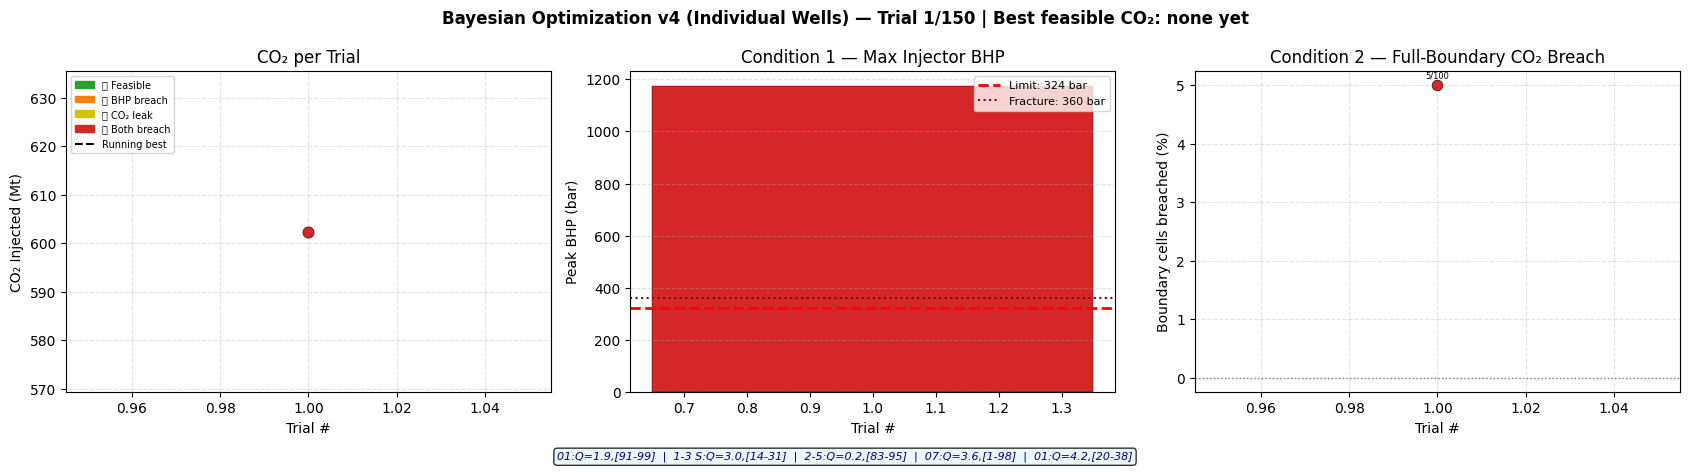


────────────────────────────────────────────────────────────
  TRIAL 2/150
────────────────────────────────────────────────────────────
   31/01/01       : Q=0.90 Mt/yr  T=[29 → 69] yr
   31/1-3 S       : Q=2.15 Mt/yr  T=[27 → 74] yr
   31/2-5         : Q=0.70 Mt/yr  T=[28 → 57] yr
   31/05/07       : Q=2.30 Mt/yr  T=[75 → 84] yr
   31/07/01       : Q=2.55 Mt/yr  T=[56 → 62] yr
   ✅ well_plan.csv written.

   ▶ Run MATLAB simulation now.
   ⏳ Waiting for new simulation folder ...
      (polls every 5 s — timeout: 30 min)



In [ ]:
# Cell 7 — Optimization Loop (v4 — Individual Wells, Handshake Mode)
#
# For each trial:
#   1. Optuna proposes 15 parameters (3 per well × 5 wells)
#   2. Python writes well_plan.csv + bo_pending.json
#   3. YOU run the MATLAB simulation manually
#   4. Python watches well_csvs/ for a new folder
#   5. Python reads results → records trial → proposes next

print('=' * 65)
print('  JOHANSEN CO₂ BO — INDIVIDUAL WELLS v4 (15 params)')
print('=' * 65)
print(f'  BHP limit     : {BHP_LIMIT_BAR:.0f} bar ({BHP_SAFETY_MARGIN*100:.0f}% below {FRACTURE_PRESSURE:.0f} bar fracture)')
print(f'  S_CO₂ limit   : {S_CO2_THRESHOLD*100:.0f}% (checked on EVERY cell along the boundary by MATLAB)')
print(f'  Injection cap  : {MAX_INJECTION_YEARS} yr')
print(f'  Trials done   : {len(study.trials)}/{N_TRIALS}')
print(f'  Wells          : {", ".join(WELL_NAMES)}')
print('=' * 65)

n_remaining = max(0, N_TRIALS - len(study.trials))
if n_remaining == 0:
    print('\n✅ All trials completed! Skip to Cell 8 for analysis.')
else:
    _accepted_folders = set(globals().get('_known_folders', set()))
    for _e in trial_log:
        if _e.get('run_folder'):
            _accepted_folders.add(_e['run_folder'])
    print(f'   Dedup guard seeded with {len(_accepted_folders)} known folders.')

    for trial_idx in range(n_remaining):
        trial_num = len(study.trials)
        print(f'\n{"─" * 60}')
        print(f'  TRIAL {trial_num + 1}/{N_TRIALS}')
        print(f'{"─" * 60}')

        # ── 1. Optuna proposes parameters (15D) ──────────────────────────
        trial = study.ask()
        params = {}
        well_params = {}  # For write_well_plan

        for w in WELL_NAMES:
            q  = trial.suggest_float(_qkey(w),  *BOUNDS[_qkey(w)],  step=0.05)
            ts = trial.suggest_int(  _tskey(w), *BOUNDS[_tskey(w)])

            # FIX (v4.1): T_end is sampled AFTER T_start, with its lower bound
            # pinned to ts + MIN_INJECTION_DURATION. Previously T_start and
            # T_end were drawn independently from overlapping ranges
            # (Ts∈[0,95], Te∈[5,100]), so T_start >= T_end occurred on a large
            # fraction of trials and those trials were discarded *after*
            # consuming a slot in the N_TRIALS budget — before MATLAB was ever
            # run. Making T_end's bound depend on T_start guarantees a valid,
            # minimum-duration injection window on every trial, so no trial is
            # ever wasted on a physically impossible schedule.
            te_lo = max(BOUNDS[_tekey(w)][0], ts + MIN_INJECTION_DURATION)
            te_hi = BOUNDS[_tekey(w)][1]
            te = trial.suggest_int(_tekey(w), te_lo, te_hi)

            params[_qkey(w)]  = q
            params[_tskey(w)] = ts
            params[_tekey(w)] = te

            well_params[w] = {'Q': q, 'T_start': ts, 'T_end': te}

            short = w.split('/')[-1]
            print(f'   {w:15s}: Q={q:.2f} Mt/yr  T=[{ts} → {te}] yr')

        # Safety net only — mathematically unreachable given the dependent
        # sampling above. Kept in case BOUNDS / MIN_INJECTION_DURATION is ever
        # edited inconsistently in Cell 2.
        any_bad_timing = any(
            well_params[w]['T_end'] - well_params[w]['T_start'] < MIN_INJECTION_DURATION
            for w in WELL_NAMES
        )
        if any_bad_timing:
            print('   ⚠️  Invalid injection window on some well — skipping (pruned). '
                  'This should be unreachable; check BOUNDS/MIN_INJECTION_DURATION in Cell 2.')
            study.tell(trial, values=[-10000.0])
            trial_log.append({'trial': trial_num, 'status': 'SKIPPED', **params})
            save_results(trial_log)
            continue

        # ── 2. Write well_plan.csv ────────────────────────────────────────
        write_well_plan(well_params)
        write_pending(trial_num, params)
        clear_signal()
        print('   ✅ well_plan.csv written.')

        # ── 3. Wait for MATLAB run ────────────────────────────────────────
        print(f'\n   ▶ Run MATLAB simulation now.')
        print(f'   ⏳ Waiting for new simulation folder ...')
        print(f'      (polls every 5 s — timeout: {POLL_TIMEOUT_SEC//60} min)\n')

        try:
            t0 = time.time()
            new_folder = None
            while True:
                _detected_folder = None

                # Path 1 — bo_signal.json
                if os.path.exists(SIGNAL_FILE):
                    try:
                        sig = json.load(open(SIGNAL_FILE))
                        sf = sig.get('run_folder', '')
                        if sf and os.path.isdir(sf):
                            _detected_folder = sf
                    except:
                        pass
                    finally:
                        clear_signal()

                # Path 2 — new folder in well_csvs/
                if _detected_folder is None:
                    current_latest = get_latest_run_folder()
                    if current_latest:
                        summary_path = os.path.join(current_latest, 'simulation_summary.txt')
                        if os.path.exists(summary_path):
                            _detected_folder = current_latest

                # Accept only if new
                if _detected_folder is not None:
                    _bn = os.path.basename(_detected_folder)
                    if _bn not in _accepted_folders:
                        new_folder = _detected_folder
                        break

                # Timeout
                elapsed = time.time() - t0
                if elapsed > POLL_TIMEOUT_SEC:
                    print(f'   ⏰ Timeout ({POLL_TIMEOUT_SEC/60:.0f} min). Skipping trial.')
                    break

                time.sleep(5)

        except KeyboardInterrupt:
            print('\n   ⌨️  Interrupted by user. Saving state and stopping.')
            save_results(trial_log)
            break

        if new_folder is None:
            study.tell(trial, state=optuna.trial.TrialState.FAIL)
            trial_log.append({**params, 'trial': trial_num, 'status': 'TIMEOUT'})
            save_results(trial_log)
            continue

        _accepted_folders.add(os.path.basename(new_folder))

        # ── 4. Parse results ──────────────────────────────────────────────
        print(f'   📁 Found: {os.path.basename(new_folder)}')
        co2_val = parse_co2_total(new_folder)
        bhp_dict = parse_per_injector_bhp(new_folder)
        boundary_info = parse_boundary_breach(new_folder)

        if co2_val is None:
            print('   ❌ Could not parse CO₂ total. Marking as FAILED.')
            study.tell(trial, state=optuna.trial.TrialState.FAIL)
            trial_log.append({**params, 'trial': trial_num, 'status': 'PARSE_ERROR',
                              'run_folder': os.path.basename(new_folder)})
            save_results(trial_log)
            continue

        max_bhp = max(bhp_dict.values()) if bhp_dict else 0.0

        # ── 5. Compute reward ─────────────────────────────────────────────
        rv = compute_reward_and_violations(co2_val, max_bhp, boundary_info)

        status_icon = '🟢' if rv['is_feasible'] else '🔴'
        print(f'   {status_icon} CO₂={co2_val:.1f} Mt  |  Max BHP={max_bhp:.1f} bar  |  '
              f'Boundary breach={rv["boundary_breach_count"]}/{rv["boundary_total_cells"]} cells '
              f'({rv["boundary_violation"]*100:.1f}%)')
        if rv['cond1_breach']:
            print(f'      ⚠️  BHP BREACH: {max_bhp:.1f} > {BHP_LIMIT_BAR:.0f} bar')
        if rv['cond2_breach']:
            print(f'      ⚠️  CO₂ PLUME BREACH at boundary (>{S_CO2_THRESHOLD*100:.0f}% on '
                  f'{rv["boundary_breach_count"]} of {rv["boundary_total_cells"]} boundary cells)')
        print(f'   Reward = {rv["reward"]:.2f}')

        # ── 6. Record trial ───────────────────────────────────────────────
        trial.set_user_attr('bhp_violation', rv['bhp_violation'])
        trial.set_user_attr('boundary_violation', rv['boundary_violation'])
        trial.set_user_attr('boundary_breach_count', rv['boundary_breach_count'])
        trial.set_user_attr('boundary_total_cells', rv['boundary_total_cells'])
        trial.set_user_attr('co2_mt', co2_val)
        trial.set_user_attr('max_bhp_bar', max_bhp)
        trial.set_user_attr('is_feasible', rv['is_feasible'])
        study.tell(trial, values=[rv['reward']])

        entry = {
            **params,
            'trial': trial_num,
            'run_folder': os.path.basename(new_folder),
            'status': 'OK',
            'co2_mt': co2_val,
            'max_bhp_bar': max_bhp,
            'is_feasible': rv['is_feasible'],
            'cond1_breach': rv['cond1_breach'],
            'cond2_breach': rv['cond2_breach'],
            'bhp_violation': rv['bhp_violation'],
            'boundary_violation': rv['boundary_violation'],
            'boundary_breach_count': rv['boundary_breach_count'],
            'boundary_total_cells': rv['boundary_total_cells'],
            'reward': rv['reward'],
        }
        trial_log.append(entry)
        save_results(trial_log)
        clear_signal()
        if os.path.exists(PENDING_FILE): os.remove(PENDING_FILE)

        # ── 7. Live chart ─────────────────────────────────────────────────
        render_live_chart(trial_log, current_params=params, n_optuna_trials=len(study.trials))

    # ── End of loop ───────────────────────────────────────────────────────
    print(f'\n{"=" * 60}')
    print(f'  Optimization complete: {len(study.trials)}/{N_TRIALS} trials.')

    feasible_trials = [t for t in study.trials
                       if t.user_attrs.get('is_feasible', False)]
    if feasible_trials:
        best = max(feasible_trials, key=lambda t: t.values[0])
        print(f'  🏆 Best feasible: CO₂={best.user_attrs["co2_mt"]:.2f} Mt')
        print(f'     Per-well params:')
        for w in WELL_NAMES:
            print(f'       {w:15s}: Q={best.params[_qkey(w)]:.2f}  '
                  f'T=[{best.params[_tskey(w)]}→{best.params[_tekey(w)]}]')
    else:
        print('  ⚠️  No feasible trial yet. The optimizer is learning — continue with more trials.')
    print(f'{"=" * 60}')

In [ ]:
# Cell 8 — Best Trial Report (v4)

feasible_trials = [t for t in study.trials if t.user_attrs.get('is_feasible', False)]
all_ok_trials   = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

print(f'Study summary: {len(study.trials)} total, {len(all_ok_trials)} complete, {len(feasible_trials)} feasible')

if feasible_trials:
    best = max(feasible_trials, key=lambda t: t.values[0])
    print(f'\n🏆 BEST FEASIBLE TRIAL')
    print(f'   CO₂ stored  : {best.user_attrs["co2_mt"]:.2f} Mt')
    print(f'   Max BHP     : {best.user_attrs["max_bhp_bar"]:.1f} bar (limit: {BHP_LIMIT_BAR:.0f})')
    print(f'   Boundary breach (full-boundary scan, {S_CO2_THRESHOLD*100:.0f}% threshold): '
          f'{best.user_attrs.get("boundary_breach_count", 0)}/'
          f'{best.user_attrs.get("boundary_total_cells", 0)} cells '
          f'({best.user_attrs.get("boundary_violation", 0.0)*100:.1f}%)')

    print(f'\n   Per-well optimal parameters:')
    print(f'   {"Well":15s}  {"Q (Mt/yr)":>10s}  {"T_start":>7s}  {"T_end":>6s}')
    print(f'   {"─"*15}  {"─"*10}  {"─"*7}  {"─"*6}')
    for w in WELL_NAMES:
        q  = best.params[_qkey(w)]
        ts = best.params[_tskey(w)]
        te = best.params[_tekey(w)]
        print(f'   {w:15s}  {q:10.2f}  {ts:7d}  {te:6d}')
else:
    print('\n⚠️  No feasible trial yet. Consider extending N_TRIALS or the optimizer is still learning.')

# Write best config to well_plan.csv for final run
if feasible_trials:
    best = max(feasible_trials, key=lambda t: t.values[0])
    best_well_params = {}
    for w in WELL_NAMES:
        best_well_params[w] = {
            'Q': best.params[_qkey(w)],
            'T_start': best.params[_tskey(w)],
            'T_end': best.params[_tekey(w)],
        }
    write_well_plan(best_well_params)
    print('\n✅ Best configuration written to well_plan.csv for final MATLAB run.')

In [ ]:
# Cell 9 — Trial Summary Table (v4)

ok_entries = [e for e in trial_log if e.get('status') == 'OK']
if not ok_entries:
    print('No completed trials yet.')
else:
    df_all = pd.DataFrame(ok_entries)
    print(f'Total entries     : {len(df_all)}')
    print(f'Successful runs   : {len(ok_entries)}')
    print(f'Cond1 breaches    : {df_all["cond1_breach"].sum()}  (BHP > {BHP_LIMIT_BAR:.0f} bar)')
    print(f'Cond2 breaches    : {df_all["cond2_breach"].sum()}  (≥1 boundary cell ≥ {S_CO2_THRESHOLD*100:.0f}% S_CO₂)')
    print(f'Fully feasible    : {(df_all["is_feasible"] == True).sum()}')
    print(f'\n   CO₂ range   : {df_all["co2_mt"].min():.1f} → {df_all["co2_mt"].max():.1f} Mt')
    print(f'   BHP range   : {df_all["max_bhp_bar"].min():.1f} → {df_all["max_bhp_bar"].max():.1f} bar')

    # Per-well Q summary
    print(f'\n   Per-well Q ranges explored:')
    for w in WELL_NAMES:
        qk = _qkey(w)
        if qk in df_all.columns:
            print(f'     {w:15s}: Q = {df_all[qk].min():.2f} → {df_all[qk].max():.2f} Mt/yr')

    # Boundary breach summary — v5: full-boundary CSV from MATLAB
    if 'boundary_violation' in df_all.columns:
        print(f'\n   Boundary CO₂ breach (full-boundary scan, limit: {S_CO2_THRESHOLD*100:.0f}%):')
        _n_breach_trials = int((df_all['cond2_breach'] == True).sum())
        print(f'     Trials with ≥1 breached cell : {_n_breach_trials} / {len(df_all)}')
        print(f'     Breach fraction range        : '
              f'{df_all["boundary_violation"].min()*100:.1f}% → {df_all["boundary_violation"].max()*100:.1f}%')
        if 'boundary_total_cells' in df_all.columns and len(df_all) > 0:
            _tc = df_all['boundary_total_cells'].iloc[0]
            print(f'     Boundary cells scanned        : {_tc}')

    # Show top trials sorted by reward
    cols_show = ['trial', 'co2_mt', 'max_bhp_bar', 'is_feasible', 'reward']
    for w in WELL_NAMES:
        cols_show.extend([_qkey(w), _tskey(w), _tekey(w)])
    cols_present = [c for c in cols_show if c in df_all.columns]
    display(df_all.sort_values('reward', ascending=False).head(20)[cols_present].style
            .format(precision=2)
            .apply(lambda row: ['background-color: #e8f5e9' if row.get('is_feasible', False)
                                else 'background-color: #fff0f0'] * len(row), axis=1)
           )

In [ ]:
# Cell 10 — Parameter Importance Analysis (v4)

try:
    importance = optuna.importance.get_param_importances(study)
    print('📊 Parameter importance (most → least):')
    for pname, imp in sorted(importance.items(), key=lambda x: -x[1]):
        bar = '█' * int(imp * 40)
        # Decode well name from param key
        print(f'   {pname:25s}: {imp:.3f}  {bar}')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    names  = list(sorted(importance.keys(), key=lambda k: -importance[k]))
    values = [importance[n] for n in names]
    # Color-code by well
    well_colors = plt.cm.tab10(np.linspace(0, 1, len(WELL_NAMES)))
    bar_colors = []
    for n in names:
        found = False
        for i, w in enumerate(WELL_NAMES):
            if _safe(w) in n:
                bar_colors.append(well_colors[i])
                found = True
                break
        if not found:
            bar_colors.append('#999999')

    ax.barh(range(len(names)), values, color=bar_colors, edgecolor='k', lw=0.3)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title('Optuna Parameter Importance (v4 — Individual Wells)')
    ax.invert_yaxis()
    # Legend
    from matplotlib.patches import Patch
    handles = [Patch(color=well_colors[i], label=w) for i, w in enumerate(WELL_NAMES)]
    ax.legend(handles=handles, fontsize=7, loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{PYTHON_DIR}/bo_v4_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'⚠️  Could not compute importance (need ≥{N_WARMUP+1} trials): {e}')

In [ ]:
# Cell 11 — Surrogate Model Export (v4)

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import joblib

ok_entries = [e for e in trial_log if e.get('status') == 'OK']
if len(ok_entries) < 10:
    print(f'⚠️  Need at least 10 OK trials to train a surrogate (have {len(ok_entries)}).')
else:
    # Build feature matrix — all 15 params
    param_keys = []
    for w in WELL_NAMES:
        param_keys.extend([_qkey(w), _tskey(w), _tekey(w)])

    X = np.array([[e[k] for k in param_keys] for e in ok_entries])
    y_co2 = np.array([e['co2_mt'] for e in ok_entries])
    y_bhp = np.array([e['max_bhp_bar'] for e in ok_entries])

    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)

    model_co2 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
    model_co2.fit(X_scaled, y_co2)

    model_bhp = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
    model_bhp.fit(X_scaled, y_bhp)

    joblib.dump(model_co2, f'{PYTHON_DIR}/johansen_v4_co2_surrogate.pkl')
    joblib.dump(model_bhp, f'{PYTHON_DIR}/johansen_v4_bhp_surrogate.pkl')
    joblib.dump(scaler,    f'{PYTHON_DIR}/johansen_v4_scaler.pkl')

    print(f'✅ Surrogate models exported ({len(ok_entries)} training samples)')
    print(f'   CO₂ model R² (train): {model_co2.score(X_scaled, y_co2):.4f}')
    print(f'   BHP model R² (train): {model_bhp.score(X_scaled, y_bhp):.4f}')

    # Feature importance from CO2 model
    print(f'\n   CO₂ surrogate — feature importance:')
    for k, imp in sorted(zip(param_keys, model_co2.feature_importances_), key=lambda x: -x[1]):
        print(f'     {k:25s}: {imp:.4f}')
